In [21]:
import matplotlib.pyplot as plt
import numpy as np

# from brian2 import *

In [22]:
# ----------------------- Models -----------------------
# --- Brian Equations ---
eqs_neurons = '''
r = clip(u, 0, 100) * Hz : Hz
dr_slow/dt = 1 / Tau_slow * (-r_slow + r**2) : Hz*Hz
du/dt = 1 / Tau * (-u + u_syn + u_r + r_ext) : 1
du_r/dt = - Theta_ur * (u_r - U_r0) + Sigma_ur * xi: 1
r_ext : 1
u_syn : 1
sum_w : 1
X : metre (constant)
Y : metre (constant)
U_r0 : 1 (constant)
Theta_ur : Hz (constant)
Sigma_ur : Hz**0.5 (constant)
Tau : second (constant)
Tau_slow : second (constant)
'''

eqs_syn = '''
dw = r_pre/Hz * r_post/Hz * (r_post - theta) : Hz (constant over dt)
ddelta_w/dt = 1 / Tau_W * (dw - delta_w) : Hz (clock-driven)
dw/dt = clip(
    Lr * (
        delta_w * (int(delta_w < 0*Hz) * int(w > 0.01) * A_ltd + int(delta_w > 0*Hz) * int(w < 0.5))
        ),
        -100*Lr*Hz, 100*Lr*Hz)
    - 1 / C * int(sum_w_pre > W_sum_max * DEG) * int(w > 0.01) * (sum_w_pre - W_sum_max * DEG) * Hz
: 1 (clock-driven)
theta = r_slow_post / R_0 : Hz (constant over dt)
u_syn_post = w * r_pre / Hz : 1 (summed)
sum_w_pre = w : 1 (summed)
Lr : 1 (constant)
W_sum_max : 1 (constant)
A_ltd : 1 (constant)
R_0 : Hz (constant)
C : 1 (constant)
Tau_W : second (constant)
DEG : 1 (constant)
'''

# --------------------- analytical ---------------------
# --- exact ----
def Z_term(tau_slow, T_ext):
    return tau_slow * (1 - np.exp(-T_ext / tau_slow))

def C3(z, T_ext, R0, u_ext, r_slow_0):
    return (z-T_ext) / R0 * np.pow(u_ext,3)

def C2(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z - 2 * T_ext) * np.pow(u_ext, 2)

def C1(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z * R0 - T_ext * R0 - z * r_slow_0 / R0) * u_ext

def C0(z, T_ext, R0, u_ext, r_slow_0):
    return z * (np.pow(R0, 2) - r_slow_0)

def r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow):
    r_j_squared = np.pow((R0 + w * u_ext), 2)
    return r_j_squared - (r_j_squared - r_slow_0) * np.exp(- T_ext / tau_slow)

def delta_w(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    # after_stim 
    u_ext = 0
    T_ext *= 3
    r_slow_0 = trace_after_stim
    
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0
    
    after_stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    return stim + after_stim

def w_star(c3 , c2, c1):
    root_term = np.sqrt(np.pow(c2, 2) - 4 * c3 * c1)
        
    return (-c2 + root_term) / (2 * c3), (-c2 - root_term) / (2 * c3)

In [23]:
def init_network(w_init, n_inputs, t_init):
    all_neurons = NeuronGroup(n_inputs + 1, eqs_neurons, method='euler')
    input_neurons = all_neurons[:n_inputs]
    output_neuron = all_neurons[n_inputs]
    synapses = Synapses(input_neurons, output_neuron, eqs_syn, method='euler')
    synapses.connect()
    
    all_neurons.Tau_slow = 1_000*ms
    all_neurons.Tau = defaultclock.dt #! CHANGED
    all_neurons.u = 2
    all_neurons.Theta_ur = 1*Hz
    
    input_neurons.U_r0 = 2
    output_neuron.U_r0 = 1
    
    synapses.R_0 = 2*Hz
    synapses.w[:] = np.clip(np.random.normal(0.05, 0.02, size=synapses.w[:].size), 0.01, 0.5)
    synapses.w[0] = w_init
    synapses.w[1:] = synapses.w[1:] / sum(synapses.w[1:]) * (0.5-w_init)
    synapses.Lr = 2e-4
    synapses.Lr[0] = 0.
    synapses.A_ltd = 1.
    synapses.Tau_W = 100*ms
    synapses.W_sum_max = 0.12
    synapses.C = 30.
    
    M = StateMonitor(all_neurons, ['r', 'r_slow'], record=True, dt=1*ms)
    S = StateMonitor(synapses, ['w', 'theta', 'dw'], record=True, dt=1*ms)
    
    net = Network(synapses, all_neurons, M, S)
    
    net.run(t_init)
    net.store("init_5_min")
    
    return net, input_neurons, output_neuron, synapses, M, S

WARNING    /var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_53255/1444965301.py:97: RuntimeWarning: invalid value encountered in scalar divide
  return (-c2 + root_term) / (2 * c3), (-c2 - root_term) / (2 * c3)
 [py.warnings]


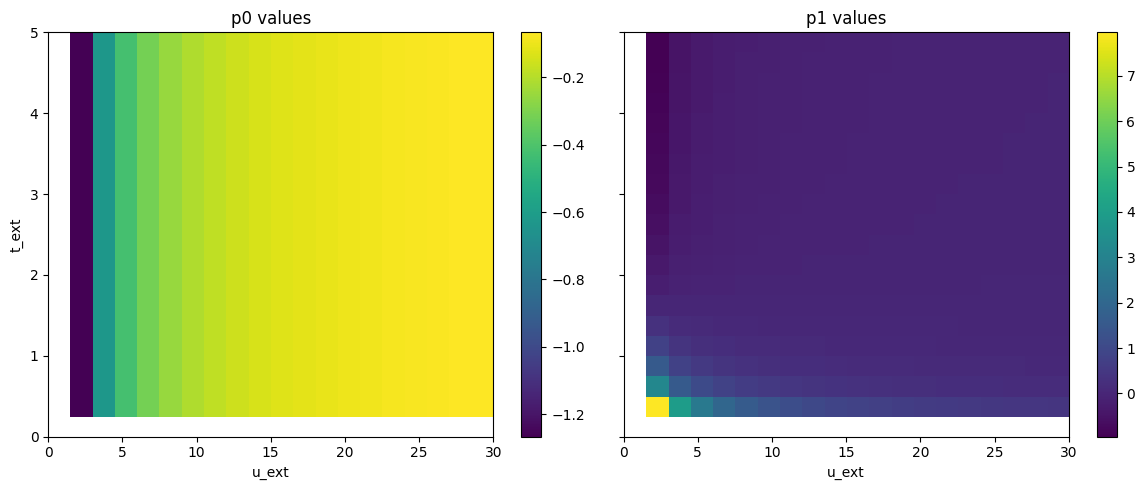

In [24]:
R_NULL = 2
ALPHA = 2e-4
R_SLOW_NULL = R_NULL**2

tau_slow = 1.0

t_exts = np.linspace(0, 5, 20)
u_exts = np.linspace(0, 30, 20)

# Allocate array to store p0 values
p0_vals = np.zeros((len(t_exts), len(u_exts), 2))

for i, t_ext in enumerate(t_exts):
    for j, u_ext in enumerate(u_exts):

        z = Z_term(tau_slow, t_ext)
        c3 = C3(z, t_ext, R_NULL, u_ext, R_SLOW_NULL)
        c2 = C2(z, t_ext, R_NULL, u_ext, R_SLOW_NULL)
        c1 = C1(z, t_ext, R_NULL, u_ext, R_SLOW_NULL)
        c0 = C0(z, t_ext, R_NULL, u_ext, R_SLOW_NULL)

        p0, p1 = w_star(c3, c2, c1)

        p0_vals[i, j, 0] = p0
        p0_vals[i, j, 1] = p1

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot p0
im0 = axes[0].imshow(
    p0_vals[:, :, 0],
    origin='lower',
    aspect='auto',
    extent=[u_exts.min(), u_exts.max(), t_exts.min(), t_exts.max()]
)
axes[0].set_title("p0 values")
axes[0].set_xlabel("u_ext")
axes[0].set_ylabel("t_ext")
fig.colorbar(im0, ax=axes[0])

# Plot p1
im1 = axes[1].imshow(
    p0_vals[:, :, 1],
    origin='lower',
    aspect='auto',
    extent=[u_exts.min(), u_exts.max(), t_exts.min(), t_exts.max()]
)
axes[1].set_title("p1 values")
axes[1].set_xlabel("u_ext")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()